### 1. **INTRODUÇÃO**
A defasagem escolar é um fenômeno educacional caracterizado pela diferença entre o nível de aprendizagem esperado para determinada etapa de ensino e o desempenho apresentado pelo aluno. Trata-se de um desafio relevante para instituições de ensino, pois pode estar associado a fatores acadêmicos, comportamentais, sociais, emocionais e psicopedagógicos, impactando a trajetória escolar e o desenvolvimento dos estudantes.

Diante disso, este projeto tem como objetivo investigar o potencial de modelos de Machine Learning na identificação precoce de alunos em risco de defasagem escolar. A proposta central consiste em analisar uma base de dados educacional contendo informações sobre desempenho acadêmico, adequação de nível, indicadores de engajamento, aspectos psicossociais e características psicopedagógicas, buscando compreender quais fatores estão associados ao aumento do risco de queda no desempenho.

Primeiramente, busca-se responder às principais perguntas da escola, identificando características dos estudantes que podem indicar sinais antecipados de dificuldade acadêmica. Na segunda etapa, serão aplicadas técnicas de machine learning para construir um modelo capaz de gerar uma estimativa de risco individual, permitindo que a instituição realize intervenções preventivas antes que ocorra a defasagem escolar.

A aplicação de modelos preditivos nesse contexto possibilita uma abordagem orientada por dados, apoiando a tomada de decisão pedagógica e contribuindo para um acompanhamento mais personalizado dos estudantes.

### 2. **COLETA DE DADOS**
Utilizou-se, neste projeto, a base de dados *<u>BASE DE DADOS PEDE 2024 - DATATHON.xlsx</u>*, disponibilizada pelos professores responsáveis pelo desafio. O arquivo, fornecido em formato XLSX, é composto por três planilhas distintas, contendo registros referentes aos anos de 2022, 2023 e 2024. Essa organização temporal possibilita a análise dos dados ao longo de diferentes períodos letivos, permitindo a identificação de padrões, variações e tendências no desempenho dos alunos.

A base reúne informações relacionadas ao desempenho acadêmico dos estudantes, além de indicadores referentes à adequação de nível, defasagem escolar, engajamento, aspectos psicossociais e psicopedagógicos. O conjunto de dados apresenta estrutura tabular e é acompanhado por um dicionário de variáveis que descreve o significado de cada atributo, permitindo a correta interpretação dos registros e orientando as etapas de limpeza, tratamento e análise exploratória dos dados.

In [277]:
# ==================================================
# BIBLIOTECAS PADRAO
# ==================================================
from datetime import datetime
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
# ==================================================
# DEMAIS BIBLIOTECAS
# ==================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import joblib

# ==================================================
# SCIKIT-LEARN
# ==================================================
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.model_selection import (
    GroupKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [278]:
# ==================================================
# COLETA DE DADOS
# ==================================================
local_arquivo = 'C:/Users/diego/Desktop/RM368720_DATATHON_FASE_05/data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

df_original = {
    ano: pd.read_excel(
        local_arquivo,
        sheet_name=f'PEDE{ano}'
    )
    for ano in [2022, 2023, 2024]
}

df_original_2022 = df_original[2022]
df_original_2023 = df_original[2023]
df_original_2024 = df_original[2024]

### 3. **ANÁLISE EXPLORATÓRIA DOS DADOS**
Durante a etapa de análise exploratória, a base de dados foi carregada e inspecionada para compreensão da estrutura dos dados e das variáveis disponíveis. A partir desse arquivo XLSX e de seu respectivo dicionário de dados, foi possível organizar o conjunto de dados, interpretar suas variáveis e preparar a base para as etapas seguintes de limpeza, análise e modelagem preditiva.

#### 3.1. VERIFICAÇÃO DA UNICIDADE DOS REGISTROS POR ALUNO
Observa-se que não há registros duplicados dentro de cada ano analisado. Dessa forma, cada linha da base de dados representa um único aluno, sem repetição de estudantes no mesmo período letivo.

In [279]:
# ==================================================
# VISAO GERAL DOS DADOS BRUTOS
# ==================================================
for ano, df in df_original.items():
    print('\n========================================================')
    print(f'PLANILHA DE {ano}')
    print('========================================================')
    print(f'Total de registros: {len(df)}')
    print(f'Total de RAs únicos: {df['RA'].nunique()}')


PLANILHA DE 2022
Total de registros: 860
Total de RAs únicos: 860

PLANILHA DE 2023
Total de registros: 1014
Total de RAs únicos: 1014

PLANILHA DE 2024
Total de registros: 1156
Total de RAs únicos: 1156


#### 3.2. CONSOLIDAÇÃO DAS BASES DE DADOS
Para viabilizar a análise temporal do desempenho dos alunos, realiza-se a consolidação das bases de dados referentes aos três períodos disponibilizados em um único *dataframe*. Como as planilhas apresentam diferenças em sua estrutura e não seguem um layout padronizado, faz-se necessário identificar a correspondência entre os campos disponíveis e realizar os ajustes necessários para a uniformização das informações. Durante esse processo, alguns dados categóricos são tratados de modo a garantir a consistência e a compatibilidade entre os diferentes períodos analisados. Adicionalmente, cria-se uma variável referente ao ano de cada registro, permitindo o controle da dimensão temporal da base consolidada e a realização das análises subsequentes.

In [280]:
# ==================================================
# ADEQUACAO DE COLUNAS CORRESPONDENTES
# ==================================================  
df_2022 = df_original_2022.rename(columns={
    'INDE 22': 'INDE',
    'Pedra 22': 'Pedra',
    'Defas': 'Defasagem',
    'Idade 22': 'Idade',
    'Fase ideal': 'Fase Ideal'
})

df_2023 = df_original_2023.rename(columns={
    'INDE 2023': 'INDE',
    'Pedra 2023': 'Pedra'
})

df_2024 = df_original_2024.rename(columns={
    'INDE 2024': 'INDE',
    'Pedra 2024': 'Pedra'
})

In [281]:
# ==================================================
# CRIACAO DE CAMPO 'IPP' FALTANTE NA BASE DE 2022
# ==================================================
df_2022['IPP'] = np.nan

# ==================================================
# DE-PARA DE VALORES NA BASE DE 2022
# ==================================================
df_2022['Pedra'] = df_2022['Pedra'].replace('Ágata', 'Agata')

In [282]:
# ==================================================
# JUNCAO DOS TRES PERIODOS EM UM UNICO DATAFRAME E CRIACAO DE COLUNA PARA CONTROLE TEMPORAL
# ================================================== 
colunas_comuns = [
    col for col in df_2024.columns
    if col in df_2023.columns and col in df_2022.columns
]

df_consolidado = pd.concat(
    [
        df_2024[colunas_comuns].assign(ano=2024),
        df_2023[colunas_comuns].assign(ano=2023),
        df_2022[colunas_comuns].assign(ano=2022)
    ],
    ignore_index=True
)

#### 3.3. VISÃO GERAL E QUALIDADE DOS DADOS

In [283]:
# ==================================================
# EXPURGO DE DADOS FALTANTES
# ================================================== 
df = df_consolidado.loc[
    (df_consolidado['INDE'] != 'INCLUIR') &
    (df_consolidado['INDE'].notna())
].copy()


In [284]:
# ==================================================
# PADRONIZACAO DO CAMPO 'FASE'
# ================================================== 
df['Fase'] = pd.to_numeric(
    pd.Series(
        np.select(
            [
                df['ano'].eq(2022),
                df['Fase'].str.strip().eq('ALFA'),
                df['ano'].eq(2023),
                df['ano'].eq(2024)
            ],
            [
                df['Fase'],
                0,
                df['Fase'].str[-1],
                df['Fase'].str[0]
            ],
            default=np.nan
        ),
        index=df.index
    ),
    errors='coerce'
).astype('Int64')

In [285]:
# ==================================================
# PADRONIZACAO DO CAMPO 'IDADE'
# ================================================== 
df['Idade'] = (
    df['Idade']
    .apply(lambda x: x.day if isinstance(x, datetime) else x)
    .astype('Int64')
)

In [286]:
# ==================================================
# DETERMINACAO DE TIPAGEM DE DADOS
# ================================================== 
colunas_int = [
    'ano',
    'Fase',
    'Idade',
    'Ano ingresso',
    'Cg',
    'Cf',
    'Ct',
    'Nº Av',
    'Defasagem'
]

colunas_float = [
    'INDE',
    'IAA',
    'IEG',
    'IPS',
    'IPP',
    'IDA',
    'IPV',
    'IAN'
]

colunas_object = [
    col for col in df.columns
    if col not in colunas_int + colunas_float
]

tipos = {
    **{col: 'Int64' for col in colunas_int},
    **{col: 'Float64' for col in colunas_float},
    **{col: 'object' for col in colunas_object}
}

df = df.astype(tipos)

In [287]:
# ==================================================
# VERIFICACAO DE ERROS
# ================================================== 
print('Total de erros do tipo "#N/D" ou "#DIV/0!":',
      int(df.isin(['#N/D', '#DIV/0!']).sum().sum()))

Total de erros do tipo "#N/D" ou "#DIV/0!": 0


In [288]:
# ==================================================
# VISAO GERAL DO CONJUNTO DE DADOS
# ================================================== 
linhas, colunas = df.shape
print(f'Shape: {linhas} linhas, {colunas} colunas.')

print('\nEstrutura do Conjunto de Dados:')
df.info()
df.head()

Shape: 2845 linhas, 37 colunas.

Estrutura do Conjunto de Dados:
<class 'pandas.core.frame.DataFrame'>
Index: 2845 entries, 0 to 3029
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     2845 non-null   object 
 1   Fase                   2845 non-null   Int64  
 2   INDE                   2845 non-null   Float64
 3   Pedra                  2845 non-null   object 
 4   Turma                  2845 non-null   object 
 5   Idade                  2845 non-null   Int64  
 6   Gênero                 2845 non-null   object 
 7   Ano ingresso           2845 non-null   Int64  
 8   Instituição de ensino  2844 non-null   object 
 9   Pedra 20               722 non-null    object 
 10  Pedra 21               1020 non-null   object 
 11  Cg                     860 non-null    Int64  
 12  Cf                     860 non-null    Int64  
 13  Ct                     860 non-null    Int64  
 

,RA,Fase,INDE,Pedra,Turma,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,ano
0,RA-1275,0,7.611367,Ametista,ALFA A - G0/G1,8,Masculino,2024,Pública,NaN,...,NaN,NaN,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,2024
1,RA-1276,0,8.002867,Topázio,ALFA A - G0/G1,8,Feminino,2024,Pública,NaN,...,NaN,NaN,7.05,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,2024
2,RA-1277,0,7.9522,Ametista,ALFA A - G0/G1,8,Masculino,2024,Pública,NaN,...,NaN,NaN,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,2024
3,RA-868,0,7.156367,Ametista,ALFA A - G0/G1,8,Masculino,2023,Pública,NaN,...,NaN,NaN,7.213333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,2024
4,RA-1278,0,5.4442,Quartzo,ALFA A - G0/G1,9,Masculino,2024,Pública,NaN,...,NaN,NaN,4.173333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,2024


In [289]:
# ==================================================
# ESTATISTICA DESCRITIVA
# ==================================================
df.describe()

,Fase,INDE,Idade,Ano ingresso,Cg,Cf,Ct,Nº Av,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Defasagem,ano
count,2845.0,2845.0,2845.0,2845.0,860.0,860.0,860.0,2845.0,2845.0,2845.0,2845.0,1985.0,2845.0,2845.0,2845.0,2845.0,2845.0
mean,2.205272,7.269915,12.056239,2021.610545,430.516279,75.519767,6.598837,3.138489,7.926578,8.229802,6.297762,7.555974,6.376784,7.54591,7.010545,-0.699473,2023.06819
std,1.822477,0.991767,2.764109,1.835201,248.432761,52.31267,3.975858,0.911991,2.617534,1.568487,1.784413,0.938275,1.957528,1.085439,2.510504,0.849847,0.817523
min,0.0,3.032,7.0,2016.0,1.0,1.0,1.0,0.0,0.0,0.0,2.5,2.5,0.0,2.5,2.5,-5.0,2022.0
25%,1.0,6.6752,10.0,2021.0,215.75,30.0,3.0,2.0,7.9,7.5,5.02,7.083333,5.1,6.966,5.0,-1.0,2022.0
50%,2.0,7.388267,12.0,2022.0,430.5,67.0,6.0,3.0,8.751,8.654244,7.5,7.5,6.666667,7.583,5.0,-1.0,2023.0
75%,3.0,7.986867,14.0,2023.0,645.25,118.0,9.0,4.0,9.5,9.4,7.51,8.125,7.833333,8.255,10.0,0.0,2024.0
max,7.0,9.531325,22.0,2024.0,862.0,192.0,18.0,6.0,10.002,10.0,10.0,10.0,10.0,10.01,10.0,3.0,2024.0


#### 3.4. VALIDAÇÃO DA GRANULARIDADE DO CONJUNTO DE DADOS CONSOLIDADO

In [290]:
print('Total de registros:', len(df))
print('Total de RAs únicos:', df['RA'].nunique())

Total de registros: 2845
Total de RAs únicos: 1586


### 4. **QUESTÕES DE NEGÓCIO NORTEADORAS DA ANÁLISE**

#### 4.1. ADEQUAÇÃO DO NÍVEL (IAN)
<u>Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo dos anos?<br>
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)</u>

In [291]:
# ==================================================
# TOTAL E PERCENTUAL DE ALUNOS EM DEFASAGEM POR ANO
# ==================================================
df_Q1_IAN = df.copy()
df_Q1_IAN = (
    df.groupby('ano')
    .agg(
        alunos=('IAN', lambda x: ((x != 10.0) | x.isna()).sum()),
        total=('IAN', 'size')
    )
    .reset_index()
)

df_Q1_IAN['alunos'] = df_Q1_IAN['alunos'].astype('Int64')

df_Q1_IAN['%'] = (
    df_Q1_IAN['alunos'] / df_Q1_IAN['total'] * 100
)

df_Q1_IAN = (
    df_Q1_IAN
    .drop(columns='total')
    .sort_values('ano')
    .reset_index(drop=True)
)

(
    df_Q1_IAN
    .style
    .hide(axis='index')
    .format({'%': '{:.1f}%'})
)

ano,alunos,%
2022,601,69.9%
2023,544,58.4%
2024,534,50.7%


<u>Resposta:</u><br>
Observa-se uma redução progressiva na quantidade de alunos em situação de defasagem moderada ou severa ao longo dos anos. Destaca-se a diminuição consistente da representatividade percentual desse grupo em relação ao total de alunos avaliados.

#### 4.2. DESEMPENHO ACADÊMICO (IDA)
<u>O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?</u>

Faz-se necessário avaliar o comportamento das medidas de tendência central da variável IDA, visando selecionar a métrica estatística mais representativa da distribuição dos dados e, consequentemente, mais adequada para responder à questão de pesquisa.

In [292]:
# ==================================================
# METRICAS ESTATISTICAS AGRUPADAS POR ANO
# ==================================================
df_Q2_IDA = df.copy()
df_Q2_IDA = (
    df.groupby('ano')['IDA']
    .agg(
        media='mean',
        mediana='median',
        desvio_padrao='std',
        assimetria='skew'
    )
    .reset_index()
    .sort_values('ano')
    .reset_index(drop=True)
)

df_Q2_IDA.style.hide(axis='index')

ano,media,mediana,desvio_padrao,assimetria
2022,6.092907,6.300000,2.046209,-0.539233
2023,6.669495,6.800000,1.594680,-0.416473
2024,6.349858,6.750000,2.132045,-0.584510


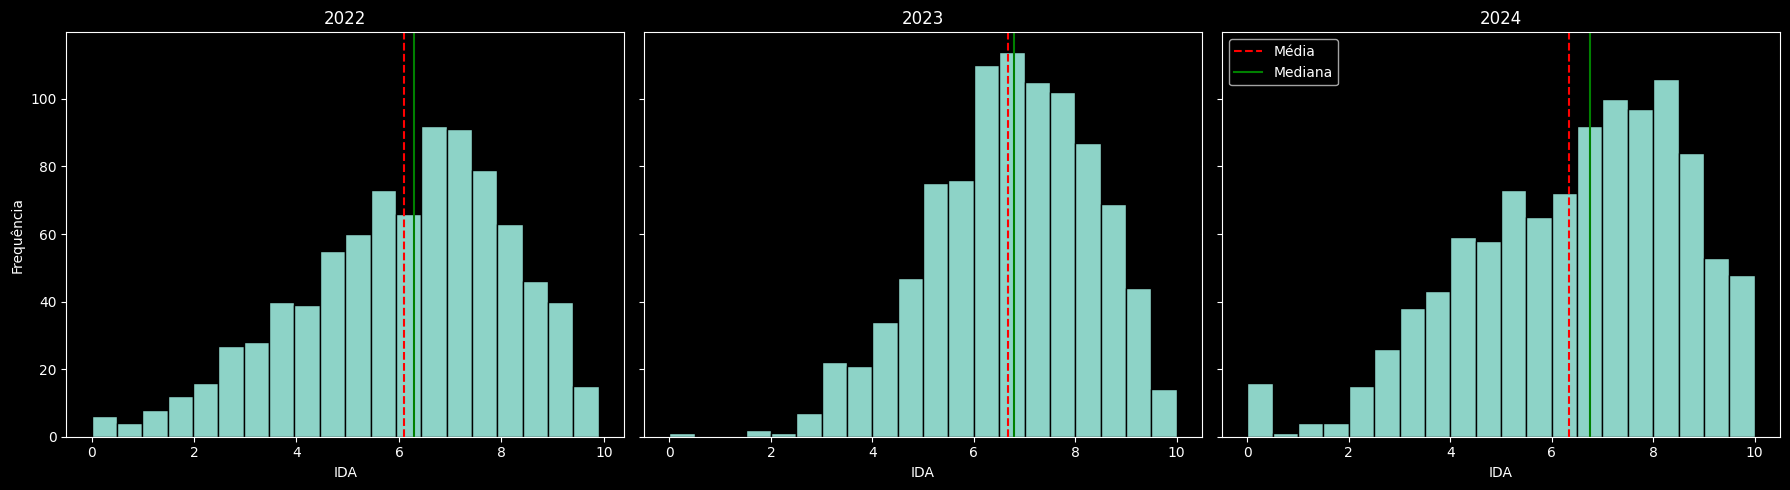

In [293]:
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

for ax, ano in zip(axes, [2022, 2023, 2024]):

    dados = df.loc[df['ano'] == ano, 'IDA']

    ax.hist(dados, bins=20, edgecolor='black')

    ax.axvline(dados.mean(), color='red', linestyle='--', label='Média')
    ax.axvline(dados.median(), color='green', label='Mediana')

    ax.set_title(f'{ano}')
    ax.set_xlabel('IDA')

axes[0].set_ylabel('Frequência')
axes[2].legend()

plt.tight_layout()
plt.show()

Para avaliar a evolução do desempenho acadêmico (IDA), adotou-se a **mediana** como medida de tendência central, por se tratar de uma estatística mais robusta à presença de valores extremos (outliers) e menos sensível à assimetria da distribuição dos dados. A análise descritiva evidenciou assimetria negativa em todos os anos avaliados, com a média consistentemente inferior à mediana, indicando que valores mais baixos de IDA influenciam a média. Nesse contexto, a mediana representa de forma mais fiel o desempenho típico dos estudantes, sendo, portanto, a métrica mais adequada para responder à questão de pesquisa.

In [294]:
# ==================================================
# MEDIANA AGRUPADA POR FASE E ANO
# ==================================================
df_Q2_comparacao = (
    df.loc[df['ano'].isin([2022, 2023, 2024])]
    .groupby(['Fase', 'ano'])['IDA']
    .agg(alunos='count', mediana='median')
    .unstack('ano')
)

df_Q2_comparacao.columns = [
    f'{metrica} {ano}' for metrica, ano in df_Q2_comparacao.columns
]

df_Q2_comparacao = (
    df_Q2_comparacao
    .reset_index()
    .sort_values('Fase')
    .reset_index(drop=True)
)

colunas_qtd = df_Q2_comparacao.filter(like='alunos').columns
colunas_mediana = df_Q2_comparacao.filter(like='mediana').columns

df_Q2_comparacao[colunas_qtd] = (
    df_Q2_comparacao[colunas_qtd]
    .fillna(0)
    .astype('Int64')
)

(
    df_Q2_comparacao
    .style
    .hide(axis='index')
    .format({col: '{:.1f}' for col in colunas_mediana})
)

Fase,alunos 2022,alunos 2023,alunos 2024,mediana 2022,mediana 2023,mediana 2024
0,190,231,196,7.3,7.8,7.8
1,192,173,185,6.8,6.9,7.2
2,155,199,185,5.5,6.8,6.5
3,148,132,211,5.2,5.7,5.0
4,76,88,115,6.1,6.0,5.7
5,60,65,100,6.5,6.0,6.8
6,18,33,25,6.8,6.8,7.3
7,21,10,37,5.0,7.8,7.1


<u>Resposta</u>:<br>
Observa-se uma tendência geral de melhora no desempenho acadêmico, embora essa evolução não seja uniforme entre todas as fases.

Do ponto de vista estatístico, a maioria das fases apresenta aumento na mediana do IDA, indicando um deslocamento positivo da distribuição do desempenho acadêmico ao longo do período. As exceções são as fases 3 e 4, que registraram redução da mediana do IDA em 2024.

Assim, as evidências sugerem que o desempenho acadêmico vem melhorando de forma geral, embora com heterogeneidade entre as fases e alguns indícios de estagnação ou queda em fases específicas.

#### 4.3. ENGAJAMENTO NAS ATIVIDADES (IEG)
<u>O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?</u>

Para avaliar a associação entre diferentes indicadores relacionados ao desempenho dos alunos, realiza-se uma análise de correlação entre tais variáveis. Isso permite observar como esses indicadores se relacionam entre si, auxiliando na compreensão de possíveis padrões entre engajamento, desempenho acadêmico e evolução dos estudantes.

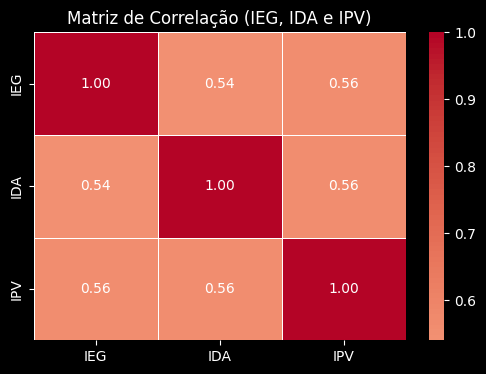

In [295]:
# ==================================================
# MATRIZ DE CORRELACAO
# ==================================================
df_Q3 = df.copy()
df_Q3_correlacao = df[['IEG', 'IDA', 'IPV']].corr().round(2)

plt.figure(figsize=(6, 4))
sns.heatmap(
    df_Q3_correlacao,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=.7,
    fmt='.2f'
)
plt.title('Matriz de Correlação (IEG, IDA e IPV)')
plt.show()

Correlações entre 0.5 e 0.6 indicam relação moderada e positiva.<br>
Ou seja: quanto maior o engajamento, maior o desempenho e maior o ponto de virada. Não é uma relação fraca, mas também não é determinística — há outros fatores envolvidos.

Para complementar a análise da relação entre os indicadores, os alunos são agrupados em diferentes faixas de **IEG** (baixo, médio e alto), permitindo observar o comportamento dos indicadores **IDA** e **IPV** em cada grupo.

Essa abordagem possibilita verificar se diferentes níveis de engajamento estão associados a diferenças no desempenho acadêmico e no engajamento, identificando possíveis tendências que não sejam evidentes apenas pela análise da correlação.

In [296]:
# ==================================================
# INDICADORES POR FAIXA DE IEG
# ==================================================
df_Q3['Faixa_IEG'] = pd.qcut(
    df_Q3['IEG'],
    q=3,
    labels=['Baixo', 'Médio', 'Alto']
)

df_Q3_IEG = (
    df_Q3.groupby(
        'Faixa_IEG',
        as_index=False,
        observed=False
    )[['IDA', 'IPV']]
    .median()
)

df_Q3_IEG.style.hide(axis='index')

Faixa_IEG,IDA,IPV
Baixo,5.166667,6.996667
Médio,6.833333,7.667000
Alto,7.500000,8.170000


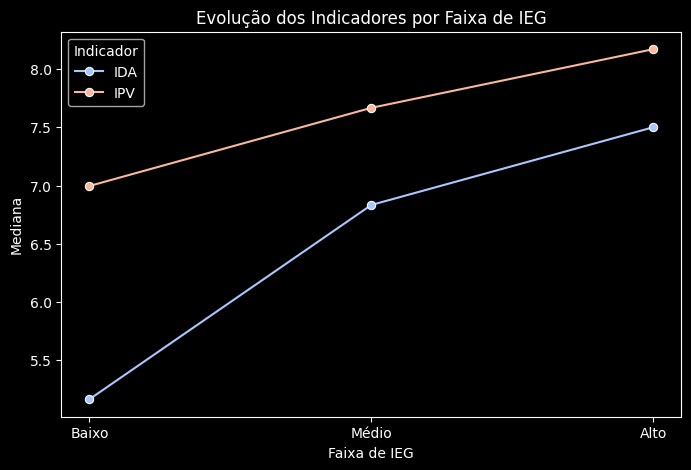

In [297]:
df_Q3_IEG_melt = df_Q3_IEG.melt(id_vars='Faixa_IEG', var_name='Indicador', value_name='Mediana')

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_Q3_IEG_melt,
    x='Faixa_IEG',
    y='Mediana',
    hue='Indicador',
    marker='o',
    palette='coolwarm'
)

plt.title('Evolução dos Indicadores por Faixa de IEG')
plt.ylabel('Mediana')
plt.xlabel('Faixa de IEG')
plt.show()

Conforme o IEG aumenta, IDA e IPV também aumentam. Isso reforça que a relação não é apenas linear, mas também estrutural: grupos mais engajados têm melhor desempenho.

Para complementar a análise, aplica-se a regressão linear considerando o **IEG** como variável explicativa e os indicadores **IDA** e **IPV** como variáveis de interesse.<br>
Essa abordagem permite avaliar como a variação no nível de engajamento se relaciona com possíveis mudanças nos indicadores analisados, além de quantificar o grau de explicação dessa relação por meio das métricas obtidas pelo modelo estatístico.

In [298]:
# ==================================================
# REGRESSAO LINEAR
# ==================================================
resultados = []

for indicador in ['IDA', 'IPV']:
    dados = df_Q3[['IEG', indicador]].dropna()

    modelo = LinearRegression().fit(
        dados[['IEG']],
        dados[indicador]
    )

    resultados.append({
        'Indicador': indicador,
        'Variação por ponto de IEG': modelo.coef_[0],
        'R²': modelo.score(dados[['IEG']], dados[indicador])
    })

resultado_regressao = (
    pd.DataFrame(resultados)
)

resultado_regressao.style.hide(axis='index')

Indicador,Variação por ponto de IEG,R²
IDA,0.678370,0.295446
IPV,0.386419,0.311795


O IEG explica cerca de 30% da variação de IDA e IPV, o que pode ser considerado significativo quando se trata de fenômenos multifatoriais.

<u>Resposta:<br></u>
Os resultados obtidos indicam que o grau de engajamento dos alunos (IEG) apresenta relação direta e positiva com os indicadores de desempenho (IDA) e com o ponto de virada (IPV), sugerindo que alunos mais engajados tendem a apresentar melhor desempenho e maior evolução ao longo do curso.

O engajamento é um fator relevante para o desempenho acadêmico e para a evolução dos alunos, embora não seja o único determinante.

#### 4.4. AUTOAVALIAÇÃO (IAA)
<u>As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?</u>

Para avaliar a relação entre a percepção dos alunos e os demais indicadores analisados, foi realizada uma análise de correlação entre as variáveis **IAA**, **IDA** e **IEG**. Essa análise permite observar a proximidade entre a percepção individual dos estudantes, seu desempenho acadêmico e seu nível de engajamento, auxiliando na identificação de possíveis associações entre esses aspectos.

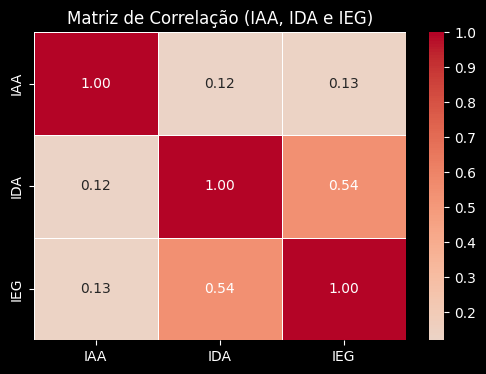

In [299]:
# ==================================================
# MATRIZ DE CORRELACAO
# ==================================================
df_Q4 = df.copy()
df_Q4_correlacao = df[['IAA', 'IDA', 'IEG']].corr().round(2)

plt.figure(figsize=(6, 4))
sns.heatmap(
    df_Q4_correlacao,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=.7,
    fmt='.2f'
)
plt.title('Matriz de Correlação (IAA, IDA e IEG)')
plt.show()

As correlações são muito fracas. Alunos que se percebem melhor não necessariamente têm melhor desempenho ou são mais engajados.<br>
O indicador IAA não é um bom preditor direto de IDA ou IEG.

Para complementar a análise de correlação, os alunos são agrupados em diferentes faixas de **IAA** (baixo, médio e alto), permitindo observar o comportamento dos indicadores **IDA** e **IEG** em cada grupo.

Essa abordagem possibilita verificar se níveis distintos de autopercepção estão associados a diferenças no desempenho acadêmico e no engajamento, identificando possíveis tendências que não sejam evidentes apenas pela análise da correlação.

In [300]:
# ==================================================
# INDICADORES POR FAIXA DE IAA
# ==================================================
df_Q4['Faixa_IAA'] = pd.qcut(
    df_Q4['IAA'],
    q=3,
    labels=['Baixo', 'Médio', 'Alto']
)

df_Q4_IAA = (
    df_Q4.groupby(
        'Faixa_IAA',
        as_index=False,
        observed=False
    )[['IDA', 'IEG']]
    .median()
)

df_Q4_IAA.style.hide(axis='index').format({
    'IDA': '{:.2f}',
    'IEG': '{:.2f}'
})

Faixa_IAA,IDA,IEG
Baixo,6.30,8.30
Médio,6.70,8.75
Alto,7.00,8.90


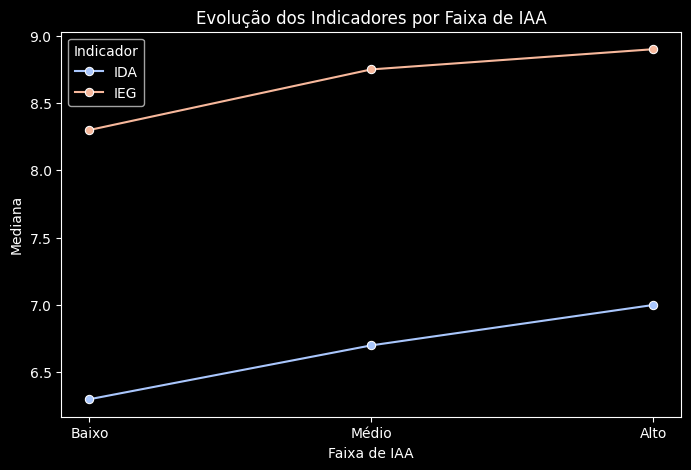

In [301]:
df_Q4_IAA_melt = df_Q4_IAA.melt(id_vars='Faixa_IAA', var_name='Indicador', value_name='Mediana')

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_Q4_IAA_melt,
    x='Faixa_IAA',
    y='Mediana',
    hue='Indicador',
    marker='o',
    palette='coolwarm'
)

plt.title('Evolução dos Indicadores por Faixa de IAA')
plt.ylabel('Mediana')
plt.xlabel('Faixa de IAA')
plt.show()

Alunos com maior autopercepção tendem a ter desempenho e engajamento um pouco maiores, porém essa tendência é fraca, coerente com a correlação baixa.

In [302]:
# ==================================================
# DESALINHAMENTOS INDIVIDUAIS
# ================================================== 
df_Q4['variacao_IAA_IDA'] = df_Q4['IAA'] - df_Q4['IDA']
df_Q4['variacao_IAA_IEG'] = df_Q4['IAA'] - df_Q4['IEG']

df_Q4[['IAA', 'IDA', 'IEG', 'variacao_IAA_IDA', 'variacao_IAA_IEG']].describe()

,IAA,IDA,IEG,variacao_IAA_IDA,variacao_IAA_IEG
count,2845.0,2845.0,2845.0,2845.0,2845.0
mean,7.926578,6.376784,8.229802,1.549794,-0.303223
std,2.617534,1.957528,1.568487,3.08237,2.869759
min,0.0,0.0,0.0,-9.9,-10.0
25%,7.9,5.1,7.5,0.335333,-1.0
50%,8.751,6.666667,8.654244,1.8,0.0
75%,9.5,7.833333,9.4,3.4,1.109143
max,10.002,10.0,10.0,9.6,9.168


Em média, os alunos se avaliam 1.55 pontos acima do desempenho real. E o desvio padrão indica que há muita variação: alguns se subestimam, outros se superestimam.
A comparação entre IAA e IEG mostra um padrão semelhante: a média é próxima de zero, mas o desvio padrão elevvado indica que a autopercepção dos alunos é influenciada por fatores subjetivos que não se refletem diretamente em seus indicadores objetivos.

<u>Resposta:</u><br>
Não, o IAA é apenas parcialmente coerente com IDA e IEG, e não representa de forma confiável o desempenho ou engajamento real dos alunos.

#### 4.5. ASPECTOS PSICOSSOCIAIS (IPS)
<u>Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?</u>

Para viabilizar uma análise temporal consistente, tornou-se necessária a construção de um dataset derivado, incorporando técnicas de feature engineering voltadas à criação de janelas temporais.  
Esse processo permite reorganizar o histórico dos estudantes em sequências comparáveis entre anos, gerar variáveis que representem a evolução dos indicadores e possibilitar a identificação de padrões de queda ou progressão ao longo do tempo.

In [303]:
# ==================================================
# PREPARACAO DOS DADOS
# ================================================== 
df_Q5 = df.copy()
df_Q5_IPS = df[['RA', 'ano', 'IPS', 'IDA', 'IEG']].copy()
df_Q5_IPS = df_Q5_IPS.sort_values(['RA', 'ano'])

# ==================================================
# EXCLUSAO DE ALUNOS COM SOMENTE 1 ANO DE HISTORICO
# ================================================== 
contagem = df_Q5_IPS['RA'].value_counts()
ra_valid = contagem[contagem >= 2].index
df_Q5_IPS = df_Q5_IPS[df_Q5_IPS['RA'].isin(ra_valid)].copy()

# ==================================================
# FEATURES TEMPORAIS (t+1)
# ================================================== 
df_Q5_IPS.loc[:, 'ano_t1'] = df_Q5_IPS.groupby('RA')['ano'].shift(-1)
df_Q5_IPS.loc[:, 'IPS_t1'] = df_Q5_IPS.groupby('RA')['IPS'].shift(-1)
df_Q5_IPS.loc[:, 'IDA_t1'] = df_Q5_IPS.groupby('RA')['IDA'].shift(-1)
df_Q5_IPS.loc[:, 'IEG_t1'] = df_Q5_IPS.groupby('RA')['IEG'].shift(-1)

# ==================================================
# FEATURES TEMPORAIS (t+2)
# ================================================== 
df_Q5_IPS.loc[:, 'ano_t2'] = df_Q5_IPS.groupby('RA')['ano'].shift(-2)
df_Q5_IPS.loc[:, 'IPS_t2'] = df_Q5_IPS.groupby('RA')['IPS'].shift(-2)
df_Q5_IPS.loc[:, 'IDA_t2'] = df_Q5_IPS.groupby('RA')['IDA'].shift(-2)
df_Q5_IPS.loc[:, 'IEG_t2'] = df_Q5_IPS.groupby('RA')['IEG'].shift(-2)

df_Q5_IPS_features = df_Q5_IPS.dropna(subset=['ano_t1']).copy()

# ==================================================
# FEATURES DE QUEDA (t+1)
# ================================================== 
df_Q5_IPS_features.loc[:, 'queda_IPS'] = np.where(
    df_Q5_IPS_features['IPS_t1'].notna(),
    (df_Q5_IPS_features['IPS_t1'] < df_Q5_IPS_features['IPS']).astype(float),
    np.nan
)

df_Q5_IPS_features.loc[:, 'queda_IDA'] = np.where(
    df_Q5_IPS_features['IDA_t1'].notna(),
    (df_Q5_IPS_features['IDA_t1'] < df_Q5_IPS_features['IDA']).astype(float),
    np.nan
)

df_Q5_IPS_features.loc[:, 'queda_IEG'] = np.where(
    df_Q5_IPS_features['IEG_t1'].notna(),
    (df_Q5_IPS_features['IEG_t1'] < df_Q5_IPS_features['IEG']).astype(float),
    np.nan
)

# ==================================================
# FEATURES DE QUEDA (t+2)
# ================================================== 
df_Q5_IPS_features.loc[:, 'queda_IPS_2'] = (
    (df_Q5_IPS_features['IPS_t2'] < df_Q5_IPS_features['IPS_t1'])
    .where(df_Q5_IPS_features['IPS_t2'].notna())
    .astype(float)
)

df_Q5_IPS_features.loc[:, 'queda_IDA_2'] = (
    (df_Q5_IPS_features['IDA_t2'] < df_Q5_IPS_features['IDA_t1'])
    .where(df_Q5_IPS_features['IDA_t2'].notna())
    .astype(float)
)

df_Q5_IPS_features.loc[:, 'queda_IEG_2'] = (
    (df_Q5_IPS_features['IEG_t2'] < df_Q5_IPS_features['IEG_t1'])
    .where(df_Q5_IPS_features['IEG_t2'].notna())
    .astype(float)
)

# ==================================================
# EXEMPLO DE CASOS COM DADOS VALIDOS
# ================================================== 
(
    df_Q5_IPS_features[df_Q5_IPS_features['ano_t2'].notnull()]
    .head()
    .reset_index(drop=True)
    .style.hide(axis='index')
)

RA,ano,IPS,IDA,IEG,ano_t1,IPS_t1,IDA_t1,IEG_t1,ano_t2,IPS_t2,IDA_t2,IEG_t2,queda_IPS,queda_IDA,queda_IEG,queda_IPS_2,queda_IDA_2,queda_IEG_2
RA-103,2022,7.500000,7.300000,8.700000,2023,5.000000,7.100000,9.200000,2024,6.260000,9.166667,9.603175,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
RA-106,2022,9.400000,7.400000,8.000000,2023,5.000000,7.300000,9.100000,2024,5.635000,5.666667,8.761905,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
RA-107,2022,7.500000,4.600000,6.400000,2023,5.000000,7.000000,8.500000,2024,7.510000,4.666667,7.994987,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
RA-110,2022,5.600000,6.700000,9.700000,2023,5.000000,7.500000,8.600000,2024,6.255000,8.500000,9.696970,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
RA-111,2022,8.100000,8.000000,9.400000,2023,5.000000,6.000000,8.700000,2024,6.260000,8.333333,9.488636,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000


A partir da identificação de queda no IPS, estimam‑se as probabilidades de ocorrência de quedas nos demais indicadores, de modo a avaliar se o comportamento negativo no componente psicossocial antecede ou se associa a reduções subsequentes em IDA e IEG. 

In [304]:
# ==================================================
# PROBABILIDADE DE QUEDA NO IDA QUANDO HA QUEDA NO IPS (t+1)
# ================================================== 
df_Q5_prob_IPS_IDA = df_Q5_IPS_features[df_Q5_IPS_features['queda_IPS'] == 1]['queda_IDA'].mean()

print('\n========================================================')
print(f'Probabilidade de queda no IDA quando há queda no IPS (t+1):', f'{df_Q5_prob_IPS_IDA:.2%}')
print('========================================================')

tabela_IDA = pd.crosstab(df_Q5_IPS_features['queda_IPS'], df_Q5_IPS_features['queda_IDA'])
print(tabela_IDA)

# ==================================================
# PROBABILIDADE DE QUEDA NO IEG QUANDO HA QUEDA NO IPS (t+1)
# ================================================== 
df_Q5_prob_IPS_IEG = df_Q5_IPS_features[df_Q5_IPS_features['queda_IPS'] == 1]['queda_IEG'].mean()

print('\n========================================================')
print(f'Probabilidade de queda no IEG quando há queda no IPS (t+1):', f'{df_Q5_prob_IPS_IEG:.2%}')
print('========================================================')

# ==================================================
# RESULTADOS
# ================================================== 
tabela_IEG = pd.crosstab(df_Q5_IPS_features['queda_IPS'], df_Q5_IPS_features['queda_IEG'])
print(tabela_IEG)


Probabilidade de queda no IDA quando há queda no IPS (t+1): 55.52%
queda_IDA  0.0  1.0
queda_IPS          
0.0        290  317
1.0        290  362

Probabilidade de queda no IEG quando há queda no IPS (t+1): 51.23%
queda_IEG  0.0  1.0
queda_IPS          
0.0        274  333
1.0        318  334


In [305]:
# ==================================================
# PROBABILIDADE DE QUEDA NO IDA QUANDO HA QUEDA NO IPS (t+2)
# ================================================== 
df_Q5_prob_IPS_IDA_2 = df_Q5_IPS_features[df_Q5_IPS_features['queda_IPS'] == 1]['queda_IDA_2'].mean()

print('\n========================================================')
print(f'Probabilidade de queda no IDA em 2 anos quando há queda no IPS (t+2):', f'{df_Q5_prob_IPS_IDA_2:.2%}')
print('========================================================')

tabela_IDA_2 = pd.crosstab(df_Q5_IPS_features['queda_IPS'], df_Q5_IPS_features['queda_IDA_2'])
print(tabela_IDA_2)

# ==================================================
# PROBABILIDADE DE QUEDA NO IDA QUANDO HA QUEDA NO IPS (t+2)
# ================================================== 
df_Q5_prob_IPS_IEG_2 = df_Q5_IPS_features[df_Q5_IPS_features['queda_IPS'] == 1]['queda_IEG_2'].mean()

print('\n========================================================')
print(f'Probabilidade de queda no IEG em 2 anos quando há queda no IPS: (t+2)', f'{df_Q5_prob_IPS_IEG_2:.2%}')
print('========================================================')

# ==================================================
# RESULTADOS
# ================================================== 
tabela_IEG_2 = pd.crosstab(df_Q5_IPS_features['queda_IPS'], df_Q5_IPS_features['queda_IEG_2'])
print(tabela_IEG_2)


Probabilidade de queda no IDA em 2 anos quando há queda no IPS (t+2): 57.82%
queda_IDA_2  0.0  1.0
queda_IPS            
0.0           60   80
1.0          124  170

Probabilidade de queda no IEG em 2 anos quando há queda no IPS: (t+2) 65.31%
queda_IEG_2  0.0  1.0
queda_IPS            
0.0           51   89
1.0          102  192


<u>Resposta:</u><br>
Os resultados sugerem que padrões psicossociais (IPS) podem anteceder quedas de desempenho acadêmico (IDA) e de engajamento (IEG), sobretudo quando observados em janelas temporais mais longas.<br>
No curto prazo (t+1), as probabilidades condicionais permanecem próximas de 50%, indicando uma associação moderada entre queda no IPS e quedas subsequentes em IDA e IEG.<br>
Entretanto, no horizonte de dois anos (t+2), essa relação se intensifica: a probabilidade de queda no IDA sobe para cerca de 58%, e a de queda no IEG ultrapassa 65%.<br>
Esse comportamento sugere que reduções no IPS podem exercer um efeito acumulado ao longo do tempo, aumentando o risco de deterioração acadêmica e de engajamento em períodos mais extensos.

#### 4.6. ASPECTOS PSICOPEDAGÓGICOS (IPP)
<u>As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?</u>

In [306]:
# ==================================================
# IPP MEDIANO POR FAIXA DE IAN E ANO
# ================================================== 
df_Q6 = df.copy()
df_Q6_IPP = (
    df.groupby(
        ['IAN', 'ano'],
        as_index=False,
        observed=False
    )[['IPP']]
    .median()
)

df_Q6_IPP_pt2 = (
    df_Q6_IPP.pivot(
        index='IAN',
        columns='ano',
        values='IPP'
    )
    .reset_index()
)

df_Q6_IPP_pt2.columns.name = None

(
    df_Q6_IPP_pt2
        .style
        .hide(axis='index')
        .format({'IAN': '{:.1f}'})
)

IAN,2022,2023,2024
2.5,,7.500000,7.031250
5.0,,7.500000,7.500000
10.0,,7.812500,7.708333


<u>Resposta:</u><br>
Conforme o IAN aumenta, o IPP também tende a aumentar. A variação é pequena, e contém algumas inversões, como em 2023.<br>
De qualquer forma, isso sugere que as avaliações psicopedagógicas **confirmam** a defasagem medida pelo IAN, ainda que de forma sutil.

#### 4.7. PONTO DE VIRADA (IPV)
<u>Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?</u>

Adotou-se três indicadores comportamentais presentes no conjunto de dados: IDA, representando o desempenho acadêmico; IEG, associado ao engajamento; e IPS, utilizado como indicador emocional por corresponder às medições relacionadas ao estado psicossocial dos estudantes.

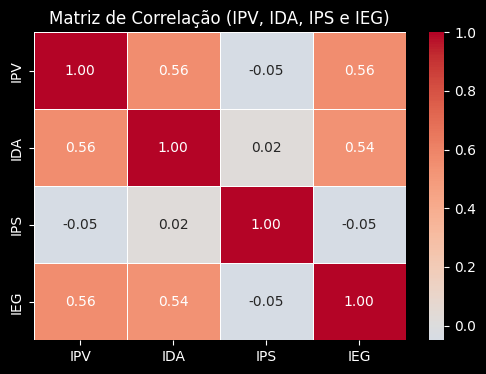

In [307]:
# ==================================================
# MATRIZ DE CORRELACAO
# ==================================================
df_Q7 = df.copy()
df_Q7_correlacao = df[['IPV', 'IDA', 'IPS', 'IEG']].corr().round(2)

plt.figure(figsize=(6, 4))
sns.heatmap(
    df_Q7_correlacao,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=.7,
    fmt='.2f'
)
plt.title('Matriz de Correlação (IPV, IDA, IPS e IEG)')
plt.show()

As correlações mostram que IDA e IEG têm relação moderada e positiva com o IPV. Isso indica que, conforme o desempenho acadêmico e o engajamento aumentam, o progresso longitudinal também tende a crescer. Já o IPS apresenta correlação praticamente nula, sugerindo que o componente emocional não se move junto com o IPV de forma linear.

In [308]:
# ==================================================
# REGRESSAO LINEAR MULTIPLA
# ==================================================
X = df_Q7[['IDA', 'IPS', 'IEG']].astype(float)
y = df_Q7['IPV'].astype(float)

X = sm.add_constant(X)
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    IPV   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     643.3
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          4.38e-319
Time:                        23:53:47   Log-Likelihood:                -3532.2
No. Observations:                2845   AIC:                             7072.
Df Residuals:                    2841   BIC:                             7096.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3708      0.103     42.464      0.0

Os coeficientes revelam que IDA e IEG contribuem de maneira significativa para o aumento do IPV, mesmo quando analisados isoladamente. O IPS apresenta efeito negativo e de pequena magnitude, indicando influência limitada.

In [309]:
# ==================================================
# IMPORTANCIA DAS FEATURES (RANDOM FOREST)
# ==================================================
modelo = RandomForestRegressor()
modelo.fit(X, y)

df_Q7_importances = (
    pd.Series(modelo.feature_importances_, index=X.columns)
      .sort_values(ascending=False)
      .reset_index()
)

df_Q7_importances.columns = ['indicador', 'importancia']
df_Q7_importances.style.hide(axis='index')

indicador,importancia
IDA,0.430638
IEG,0.408523
IPS,0.160839
const,0.000000


A análise de importância mostra que IDA é o indicador mais útil para explicar o IPV, seguido por IEG. O IPS aparece com relevância bem menor. Isso reforça que, ao aprender padrões nos dados, o modelo considera desempenho e engajamento como os principais elementos que influenciam o IPV.

In [310]:
# ==================================================
# ANALISE LONGITUDINAL (MIXED LM)
# ==================================================
modelo = smf.mixedlm('IPV ~ IDA + IPS + IEG', df, groups=df['RA'])
print(modelo.fit().summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: IPV       
No. Observations: 2845    Method:             REML      
No. Groups:       1586    Scale:              0.5599    
Min. group size:  1       Log-Likelihood:     -3520.3010
Max. group size:  3       Converged:          Yes       
Mean group size:  1.8                                   
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      4.540    0.107 42.270 0.000  4.330  4.751
IDA            0.197    0.010 20.090 0.000  0.177  0.216
IPS           -0.040    0.009 -4.454 0.000 -0.058 -0.022
IEG            0.243    0.012 20.028 0.000  0.219  0.267
Group Var      0.146    0.035                           



A análise longitudinal confirma que IEG é o fator que mais impulsiona o IPV ao longo do tempo, seguido por IDA. O IPS mantém efeito negativo e discreto.

<u>Resposta:</u><br>
Engajamento (IEG) e desempenho (IDA) são os comportamentos que mais influenciam o IPV ao longo do tempo. O indicador emocional (IPS) apresenta efeito mais discreto, contribuindo de forma complementar para a compreensão do progresso longitudinal.

#### 4.8. MULTIDIMENSIONALIDADE DOS INDICADORES
<u>Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?</u>

Para avaliar como diferentes combinações de indicadores podem estar relacionadas à nota global do aluno (**INDE**), pode-se aplicar a regressão linear múltipla considerando os indicadores **IDA**, **IEG**, **IPS** e **IPP** como variáveis explicativas.

Além dos efeitos individuais de cada indicador, são incluídas interações entre as variáveis, permitindo analisar se a combinação de determinados fatores apresenta uma relação diferenciada com o desempenho global dos alunos.

Essa abordagem possibilita uma compreensão mais ampla dos fatores associados ao INDE, considerando não apenas a contribuição isolada de cada indicador, mas também a influência conjunta entre eles.

In [311]:
# ==================================================
# REGRESSAO LINEAR MULTIPLA COM INTERACOES
# ==================================================
df_Q8 = df[df['IPP'].notna()].copy() # EXCLUSAO DE DADOS FALTANTES
df_Q8_rl = df_Q8.copy()

df_Q8_rl['IDA_IEG'] = df_Q8_rl['IDA'] * df_Q8_rl['IEG']
df_Q8_rl['IDA_IPS'] = df_Q8_rl['IDA'] * df_Q8_rl['IPS']
df_Q8_rl['IDA_IPP'] = df_Q8_rl['IDA'] * df_Q8_rl['IPP']
df_Q8_rl['IEG_IPS'] = df_Q8_rl['IEG'] * df_Q8_rl['IPS']
df_Q8_rl['IEG_IPP'] = df_Q8_rl['IEG'] * df_Q8_rl['IPP']
df_Q8_rl['IPS_IPP'] = df_Q8_rl['IPS'] * df_Q8_rl['IPP']

X_int = df_Q8_rl[['IDA', 'IEG', 'IPS', 'IPP',
                 'IDA_IEG', 'IDA_IPS', 'IDA_IPP',
                 'IEG_IPS', 'IEG_IPP', 'IPS_IPP']].astype(float)
y = df_Q8_rl['INDE'].astype(float)

X_int = sm.add_constant(X_int)
modelo_int = sm.OLS(y, X_int).fit()
print(modelo_int.summary())
print('AIC interações:', modelo_int.aic)
print('BIC interações:', modelo_int.bic)

                            OLS Regression Results                            
Dep. Variable:                   INDE   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     944.6
Date:                Sat, 25 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:53:50   Log-Likelihood:                -999.31
No. Observations:                1985   AIC:                             2021.
Df Residuals:                    1974   BIC:                             2082.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1401      0.416      2.742      0.0

Todos os indicadores apresentam efeitos positivos e significativos. Isso mostra que, transversalmente, todos eles contribuem para elevar o INDE, com destaque para o IPP.

Entre as interações testadas, duas se destacam:<br>
**IDA × IEG**: combinação positiva; alunos com bom desempenho acadêmico e alto engajamento escolar têm ganhos adicionais no INDE.<br>
**IDA × IPP**: interação negativa: quando IDA e IPP crescem simultaneamente, o ganho no INDE é menor do que o esperado pela soma dos efeitos individuais.

Considerando a estrutura longitudinal dos dados, aplica-se o modelo *Mixed Linear Model* para avaliar a relação entre os indicadores **IDA**, **IEG**, **IPS** e **IPP** e a variação do **INDE** ao longo dos registros de cada aluno.

Essa abordagem considera a existência de múltiplas observações para um mesmo estudante, permitindo incorporar as particularidades individuais de cada aluno na análise e obter uma avaliação mais adequada da relação entre os indicadores e o desempenho global.

In [312]:
# ==================================================
# ANALISE LONGITUDINAL (MIXED LM)
# ==================================================
df_Q8_lm = df_Q8.copy()

model = smf.mixedlm(
    'INDE ~ IDA + IEG + IPS + IPP',
    df_Q8_lm,
    groups=df_Q8_lm['RA']
).fit()

print(model.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: INDE      
No. Observations: 1985    Method:             REML      
No. Groups:       1307    Scale:              0.1326    
Min. group size:  1       Log-Likelihood:     -1033.9928
Max. group size:  2       Converged:          Yes       
Mean group size:  1.5                                   
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  1.401     0.090  15.517  0.000   1.224   1.578
IDA        0.236     0.006  40.327  0.000   0.225   0.248
IEG        0.249     0.007  33.910  0.000   0.235   0.263
IPS        0.121     0.005  25.910  0.000   0.112   0.130
IPP        0.214     0.011  19.311  0.000   0.192   0.236
Group Var  0.033     0.022                               



<u>Resposta:</u><br>
IEG e IDA são os pilares mais consistentes do desempenho global ao longo do tempo.<br>
IPP é o indicador mais forte em análises transversais, mas perde intensidade quando controladas as diferenças individuais.<br>
A combinação IDA + IEG é a única interação que potencializa o INDE de forma robusta.

#### 4.9. PREVISÃO DE RISCO COM MACHINE LEARNING
<u>Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?<br>
Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.</u>

##### 4.9.1. Feature engineering e preparação dos dados

Antes da etapa de modelagem, realiza-se o processo de Feature Engineering para adequar os dados ao problema de previsão. Como o objetivo é identificar alunos em risco antes da ocorrência de uma piora na defasagem, são criadas features temporais, associando cada registro de um aluno ao seu desempenho na avaliação imediatamente seguinte (t+1). Essa estratégia permite comparar a situação atual com a evolução futura do estudante, tornando possível construir a variável target, que indica se houve piora na defasagem entre duas avaliações consecutivas.

In [313]:
# ==================================================
# FEATURE ENGINEERING
# ==================================================
df_Q9_ml = df.copy()

df_Q9_ml = (
    df_Q9_ml
    .sort_values(by=['RA', 'ano'])
    .reset_index(drop=True)
)

# ==================================================
# FEATURES TEMPORAIS (t+1)
# ==================================================
df_Q9_ml['ano_t1'] = (
    df_Q9_ml.groupby('RA')['ano']
         .shift(-1)
)

df_Q9_ml['defasagem_t1'] = (
    df_Q9_ml.groupby('RA')['Defasagem']
         .shift(-1)
)

df_Q9_ml = df_Q9_ml[
    df_Q9_ml['ano_t1'] == df_Q9_ml['ano'] + 1
].copy()

# Premissa: o risco não está associado apenas a alunos já em situação de defasagem, mas a qualquer piora em sua trajetória acadêmica.
df_Q9_ml['risco'] = ( 
    df_Q9_ml['defasagem_t1'] < df_Q9_ml['Defasagem']
).astype(int)

df_Q9_ml.head().style.hide(axis='index')

RA,Fase,INDE,Pedra,Turma,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Avaliador4,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,ano,ano_t1,defasagem_t1,risco
RA-1000,0,7.916200,Ametista,ALFA U - G2/G3,8,Feminino,2023,Pública,nan,nan,,,,2,Avaliador-13,nan,Avaliador-3,nan,nan,nan,8.500000,9.400000,3.770000,6.250000,nan,7.000000,nan,nan,8.920000,10.000000,ALFA (1° e 2° ano),0,nan,nan,nan,2023,2024,0,0
RA-1001,0,8.116200,Topázio,ALFA U - G2/G3,9,Feminino,2023,Pública,nan,nan,,,,2,Avaliador-13,nan,Avaliador-3,nan,nan,nan,9.000000,9.100000,7.520000,7.500000,nan,7.800000,nan,nan,9.170000,5.000000,Fase 1 (3° e 4° ano),-1,nan,nan,nan,2023,2024,-1,0
RA-1002,0,7.901200,Ametista,ALFA U - G2/G3,9,Feminino,2023,Pública,nan,nan,,,,2,Avaliador-13,nan,Avaliador-3,nan,nan,nan,9.000000,9.700000,7.520000,6.250000,nan,7.000000,nan,nan,8.920000,5.000000,Fase 1 (3° e 4° ano),-1,nan,nan,nan,2023,2024,-1,0
RA-1003,0,7.652200,Ametista,ALFA V - G0/G1,8,Masculino,2023,Pública,nan,nan,,,,2,Avaliador-11,nan,Avaliador-2,nan,nan,nan,9.000000,8.500000,7.520000,7.500000,nan,4.000000,nan,nan,8.750000,10.000000,ALFA (1° e 2° ano),0,nan,nan,nan,2023,2024,-1,1
RA-1004,0,8.313700,Topázio,ALFA V - G0/G1,8,Feminino,2023,Pública,nan,nan,,,,2,Avaliador-11,nan,Avaliador-2,nan,nan,nan,9.000000,9.600000,7.520000,6.875000,nan,7.900000,nan,nan,7.420000,10.000000,ALFA (1° e 2° ano),0,nan,nan,nan,2023,2024,-1,1


Após a construção da variável target, é importante verificar sua distribuição entre as classes. Em problemas de classificação, um desbalanceamento significativo pode influenciar o processo de treinamento dos modelos, favorecendo a classe mais frequente e reduzindo a capacidade de identificar corretamente os casos de interesse.

In [314]:
# ==================================================
# BALANCEAMENTO DA VARIAVEL TARGET
# ==================================================
risco = (
    df_Q9_ml['risco']
    .value_counts()
    .rename_axis('classe_risco')
    .reset_index(name='alunos')
)

risco['percentual'] = (
    risco['alunos'] /
    risco['alunos'].sum() * 100
)

risco.style.format({
    'percentual': '{:.1f}%'
}).hide(axis='index')

classe_risco,alunos,percentual
0,1022,81.9%
1,226,18.1%


Para minimizar os efeitos desse desbalanceamento, optou-se por utilizar o parâmetro **class_weight='balanced'** nos modelos de machine learning a seguir.
Dessa forma, os modelos atribuem maior peso à classe minoritária durante o treinamento, reduzindo o viés em favor da classe mais frequente e permitindo uma identificação mais equilibrada dos alunos em risco.

Como a análise possui uma estrutura longitudinal por aluno, em que um mesmo estudante pode possuir registros em diferentes anos, a divisão dos conjuntos de treino e teste foi realizada considerando seu RA.

Dessa forma, todos os registros de um mesmo aluno permanecem integralmente em apenas um dos conjuntos. Essa estratégia garante que a avaliação do modelo seja realizada considerando alunos distintos entre treino e teste, preservando a consistência da análise.

In [315]:
# ==================================================
# SEPARACAO DOS CONJUNTOS EM TREINO E TESTE POR ALUNO
# ==================================================
alunos = df_Q9_ml['RA'].unique()

alunos_treino, alunos_teste = train_test_split(
    alunos,
    test_size=0.20,
    random_state=42
)

df_treino = (
    df_Q9_ml[
        df_Q9_ml['RA'].isin(alunos_treino)
    ]
    .copy()
)

df_teste = (
    df_Q9_ml[
        df_Q9_ml['RA'].isin(alunos_teste)
    ]
    .copy()
)

print('Alunos treino:', df_treino['RA'].nunique())
print('Alunos teste :', df_teste['RA'].nunique())

print('\nRegistros treino:', len(df_treino))
print('Registros teste :', len(df_teste))

# ==================================================
# VERIFICACAO DE DUPLICIDADE DE ALUNOS ENTRE OS GRUPOS DE TREINO E TESTE
# ==================================================
intersecao = set(df_treino['RA']).intersection(
    set(df_teste['RA'])
)

print(f'\nAlunos duplicados entre treino e teste: {len(intersecao)}')

Alunos treino: 651
Alunos teste : 163

Registros treino: 995
Registros teste : 253

Alunos duplicados entre treino e teste: 0


Define-se as variáveis utilizadas como **features** do modelo e a variável de interesse (**target**).<br>
As features correspondem aos indicadores utilizados como entrada do modelo, enquanto a variável target (risco) representa o resultado que será predito.

In [316]:
# ==================================================
# DEFINICAO DAS FEATURES
# ==================================================
features = [
    'INDE',
    'IDA',
    'IAA',
    'IEG',
    'IPS',
    'IPP',
    'IPV',
    'Defasagem'
]

X_train = df_treino[features]
y_train = df_treino['risco']

X_test = df_teste[features]
y_test = df_teste['risco']

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 995 entries, 3 to 2839
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   INDE       995 non-null    Float64
 1   IDA        995 non-null    Float64
 2   IAA        995 non-null    Float64
 3   IEG        995 non-null    Float64
 4   IPS        995 non-null    Float64
 5   IPP        539 non-null    Float64
 6   IPV        995 non-null    Float64
 7   Defasagem  995 non-null    Int64  
dtypes: Float64(7), Int64(1)
memory usage: 77.7 KB


Foram selecionados dois modelos de classificação com características complementares: **Regressão Logística** e **Random Forest**.

A **Regressão Logística** foi escolhida por ser um modelo estatístico interpretável, permitindo compreender a relação entre as variáveis de entrada e a probabilidade de ocorrência da classe de interesse. Além disso, serve como um modelo de referência (*baseline*) para comparação com abordagens mais complexas.

O **Random Forest** foi utilizado por ser um modelo baseado em árvores de decisão capaz de capturar relações não lineares e interações entre as variáveis preditoras, apresentando maior flexibilidade para identificar padrões mais complexos presentes nos dados.

Ambos os modelos foram implementados em pipelines contendo as etapas necessárias de pré-processamento e treinamento. Para lidar com possíveis valores ausentes, foi aplicada a imputação pela mediana. No caso da Regressão Logística, também foi realizada a padronização das variáveis, uma vez que o modelo é sensível à escala dos atributos. Além disso, ambos os modelos utilizaram o balanceamento de classes (*class_weight='balanced'*) para reduzir o impacto do desbalanceamento entre as classes.

##### 4.9.2. Treinamento e avaliação dos modelos de machine learning

In [317]:
# ==================================================
# PIPELINES DOS MODELOS DE MACHINE LEARNING
# ==================================================
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('modelo', RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ))
])

In [318]:
# ==================================================
# TREINAMENTO DOS MODELOS DE MACHINE LEARNING
# ==================================================
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

In [319]:
# ==================================================
# PREDICOES DOS MODELOS DE MACHINE LEARNING
# ==================================================
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]

y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:,1]

In [320]:
# ==================================================
# RELATORIO DE CLASSIFICACAO
# ================================================== 
print('\n========================================================')
print('REGRESSAO LOGISTICA')
print('========================================================')
print(classification_report(y_test, y_pred_lr))

print('\n\n========================================================')
print('RANDOM FOREST')
print('========================================================')
print(classification_report(y_test, y_pred_rf))


REGRESSAO LOGISTICA
              precision    recall  f1-score   support

           0       0.89      0.75      0.81       204
           1       0.37      0.61      0.46        49

    accuracy                           0.72       253
   macro avg       0.63      0.68      0.63       253
weighted avg       0.79      0.72      0.74       253



RANDOM FOREST
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       204
           1       0.46      0.57      0.51        49

    accuracy                           0.79       253
   macro avg       0.67      0.70      0.69       253
weighted avg       0.81      0.79      0.79       253



Os modelos de **Regressão Logística** e **Random Forest** foram avaliados considerando diferentes métricas de classificação, com maior atenção às métricas relacionadas à identificação dos alunos em situação de risco.

De forma geral, ambos os modelos apresentaram maior capacidade de identificar corretamente os alunos classificados sem risco, enquanto a identificação da classe de risco apresentou maior dificuldade, característica esperada em virtude do desbalanceamento entre as classes.

O **Random Forest** apresentou desempenho superior à Regressão Logística nas principais métricas avaliadas, indicando maior capacidade de capturar padrões presentes nos dados. Além disso, o modelo apresentou melhor equilíbrio entre precisão e sensibilidade na identificação dos alunos em risco.

Apesar do desempenho observado, os resultados reforçam a importância de considerar o contexto da aplicação, uma vez que a identificação de alunos em risco envolve um equilíbrio entre evitar classificações incorretas e garantir a detecção dos casos que demandam maior atenção.

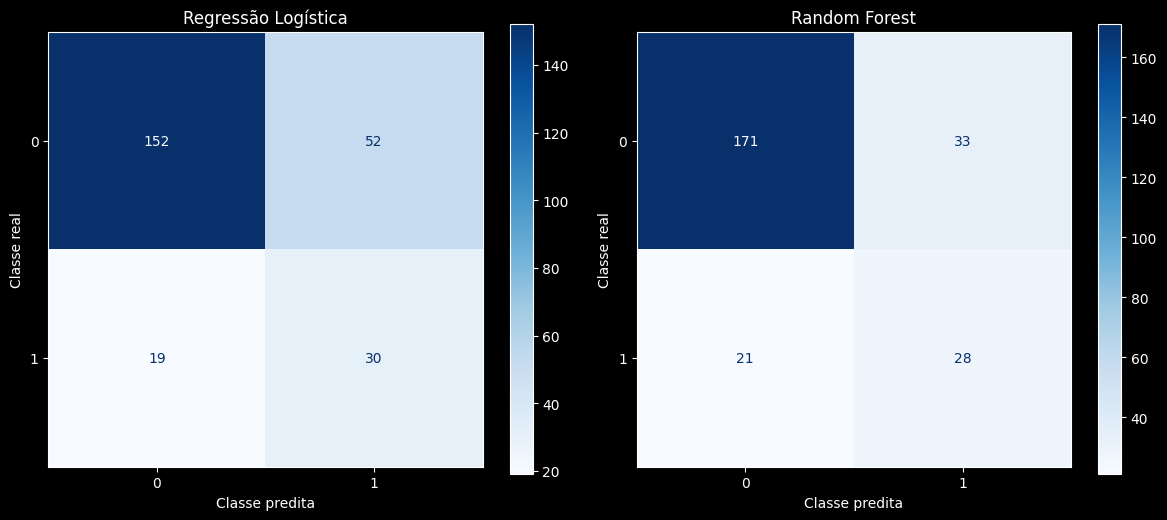

In [321]:
# ==================================================
# MATRIZ DE CONFUSAO
# ==================================================
modelos = [
    ('Regressão Logística', y_pred_lr),
    ('Random Forest', y_pred_rf)
]

fig, axes = plt.subplots(1, len(modelos), figsize=(12, 5))

for ax, (nome, predicao) in zip(axes, modelos):
    matriz = confusion_matrix(y_test, predicao)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(nome)
    ax.set_xlabel('Classe predita')
    ax.set_ylabel('Classe real')

plt.tight_layout()
plt.show()

A matriz de confusão permite detalhar o comportamento dos modelos na classificação dos alunos, comparando as classes reais com as classes previstas.

A **Regressão Logística** classificou corretamente 152 alunos sem risco e 30 alunos em situação de risco. Entretanto, apresentou 52 casos classificados como sem risco quando o aluno realmente pertencia à classe de risco, indicando maior dificuldade na identificação desses casos.

O **Random Forest** apresentou uma quantidade maior de acertos na classe sem risco, com 171 classificações corretas, além de reduzir os casos em que alunos em risco foram classificados incorretamente como sem risco (33 casos). Para a classe de risco, o modelo identificou corretamente 28 alunos, mantendo um comportamento semelhante ao observado na Regressão Logística.

De forma geral, a análise da matriz de confusão reforça que o **Random Forest apresenta maior capacidade de classificação global**, principalmente pela redução de falsos negativos, contribuindo para uma identificação mais adequada dos alunos que podem demandar maior atenção.

In [322]:
# ==================================================
# COMPARACAO DOS MODELOS DE MACHINE LEARNING - PRINCIPAIS METRICAS
# ==================================================
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

comparacao_modelos = pd.DataFrame({
    'Modelo': [
        'Regressão Logística',
        'Random Forest'
    ],
    'Accuracy': [
        (y_pred_lr == y_test).mean(),
        (y_pred_rf == y_test).mean()
    ],
    'ROC-AUC': [
        auc_lr,
        auc_rf
    ]
})

comparacao_modelos.style.format({
    'Accuracy': '{:.3f}',
    'ROC-AUC': '{:.3f}'
}).hide(axis='index')

Modelo,Accuracy,ROC-AUC
Regressão Logística,0.719,0.765
Random Forest,0.787,0.797


Para complementar a avaliação dos modelos, compara-se as métricas de **Accuracy** e **ROC-AUC**, permitindo uma análise conjunta da capacidade de classificação e da capacidade de distinção entre as classes.

A métrica **Accuracy** representa a proporção de classificações realizadas corretamente, enquanto a **ROC-AUC** avalia a capacidade do modelo em diferenciar alunos em situação de risco e sem risco considerando diferentes limiares de decisão.

A comparação entre os modelos indica que o **Random Forest** apresentou desempenho superior à **Regressão Logística** em ambas as métricas avaliadas, demonstrando maior capacidade preditiva para o conjunto de dados analisado.

Esses resultados reforçam a escolha do Random Forest como modelo principal para as análises posteriores, considerando seu melhor equilíbrio entre desempenho geral e capacidade de separação das classes.

##### 4.9.3. Interpretação dos modelos de machine learning

Após o treinamento dos modelos, são avaliadas as contribuições das variáveis utilizadas como entrada para compreender como cada indicador influencia as previsões realizadas.

Na **Regressão Logística**, essa análise é realizada por meio de seus **coeficientes**, que representam a direção e a magnitude da relação entre cada variável preditora e a probabilidade de ocorrência da classe de interesse. Coeficientes positivos indicam maior associação com a classe target, enquanto coeficientes negativos indicam uma relação inversa.

Para a **Random Forest**, a interpretação é realizada a partir da **importância das variáveis**, que indica a contribuição relativa de cada feature para as decisões tomadas pelo conjunto de árvores. Essa medida permite identificar quais indicadores possuem maior influência na capacidade preditiva do modelo.

A observação dessas métricas é fundamental para complementar a avaliação de desempenho dos modelos, permitindo identificar os principais fatores associados às previsões e contribuindo para a interpretação dos resultados.

In [323]:
# ==================================================
# COEFICIENTES - REGRESSAO LOGISTICA
# ==================================================
modelo_lr = pipeline_lr.named_steps['modelo']

coeficientes_lr = pd.DataFrame({
    'variavel': features,
    'coeficiente': modelo_lr.coef_[0]
})

coeficientes_lr = coeficientes_lr.sort_values(
    by='coeficiente',
    ascending=False
)

coeficientes_lr.style.hide(axis='index')

variavel,coeficiente
Defasagem,1.607209
IPS,0.484085
IAA,0.350145
IEG,0.199207
IDA,0.113025
IPV,-0.428518
IPP,-0.587760
INDE,-0.668765


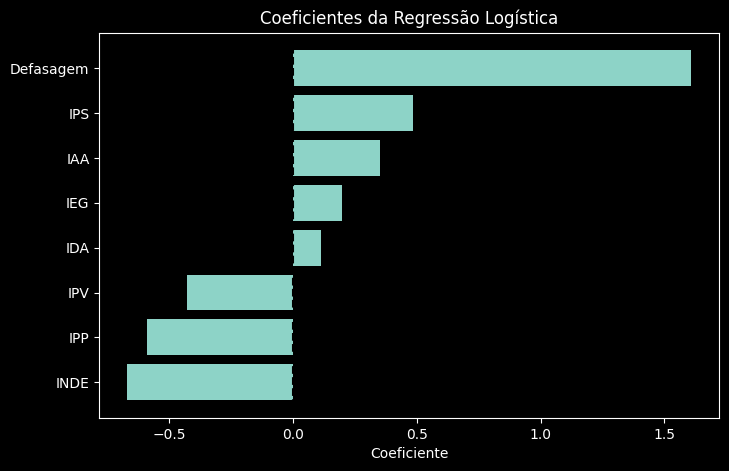

In [324]:
# ==================================================
# COEFICIENTES - REGRESSAO LOGISTICA (VISUALIZACAO GRAFICA)
# ==================================================
plt.figure(figsize=(8,5))

plt.barh(
    coeficientes_lr['variavel'],
    coeficientes_lr['coeficiente']
)

plt.axvline(0, color='black', linestyle='--')
plt.gca().invert_yaxis()

plt.xlabel('Coeficiente')
plt.title('Coeficientes da Regressão Logística')
plt.show()

In [325]:
# ==================================================
# IMPORTANCIA DAS VARIÁVEIS - RANDOM FOREST
# ==================================================
modelo_rf = pipeline_rf.named_steps['modelo']

importancias_rf = pd.DataFrame({
    'variavel': features,
    'importancia': modelo_rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by='importancia',
    ascending=False
)

importancias_rf.style.hide(axis='index')

variavel,importancia
Defasagem,0.257512
IPV,0.162540
IPP,0.128179
IDA,0.120251
INDE,0.117802
IEG,0.078968
IPS,0.067748
IAA,0.067002


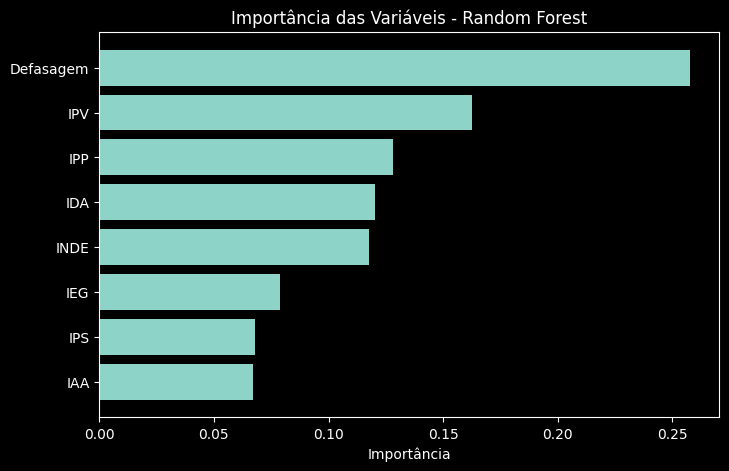

In [326]:
# ==================================================
# IMPORTANCIA DAS VARIÁVEIS - RANDOM FOREST (VISUALIZACAO GRAFICA)
# ==================================================
plt.figure(figsize=(8,5))

plt.barh(
    importancias_rf['variavel'],
    importancias_rf['importancia']
)

plt.gca().invert_yaxis()

plt.xlabel('Importância')
plt.title('Importância das Variáveis - Random Forest')
plt.show()

Na **Regressão Logística**, os coeficientes indicam a direção e a intensidade da associação de cada variável com a classificação de risco. Observa-se maior influência da variável Defasagem, seguida por indicadores como IPS, IAA e IEG, enquanto variáveis como IPP, IPV e INDE apresentam relação inversa com a probabilidade estimada de risco.

No **Random Forest**, a análise de importância das variáveis evidencia quais atributos mais contribuíram para as decisões do conjunto de árvores. Nesse modelo, a variável Defasagem também apresentou maior relevância, seguida por IPV, IPP, IDA e INDE, indicando maior participação desses indicadores na capacidade preditiva do modelo.

<u>Resposta</u>:<br>
Adotou-se como premissa que o risco não está associado apenas a alunos já em situação de elevada defasagem, mas a qualquer piora em sua trajetória acadêmica. Assim, manteve-se a defasagem atual como um dos preditores do modelo, representando a condição atual do estudante, enquanto a variável alvo foi construída para identificar qualquer redução da defasagem entre avaliações consecutivas.

Dessa forma, tanto um aluno que evolui de 3 para 2 quanto um aluno que passa de 0 para -1 são considerados casos de risco, pois ambos apresentam perda de desempenho em relação ao período anterior.

A análise dos modelos mostra que a defasagem atual foi o indicador mais relevante para antecipar esse risco, seguida pelos indicadores IPV, IPP, IDA e INDE, que também contribuíram significativamente para a previsão. Esses resultados indicam que a combinação entre a situação atual do aluno e seus indicadores de desempenho permite identificar padrões associados à probabilidade de queda futura, possibilitando intervenções pedagógicas antes que a defasagem se agrave.

##### 4.9.4. Validação do modelo de machine learning

Após a escolha pelo modelo **Random Forest**, este foi aplicado ao conjunto de teste para estimar a probabilidade de risco de piora da defasagem associada a cada aluno.

Além da classificação final, foram armazenadas as probabilidades preditas pelo modelo, permitindo uma análise mais detalhada do grau de risco estimado para cada registro.

Na visualização abaixo, a ordenação dos registros pela **probabilidade_risco** permite identificar os alunos com maiores e menores probabilidades estimadas, possibilitando uma análise mais direcionada dos casos de maior atenção e apoiando a interpretação dos resultados gerados pelo modelo.

In [327]:
# ==================================================
# APLICACAO DO MODELO DE MACHINE LEARNING - RANDOM FOREST
# ==================================================
resultado_rf = df_teste.copy()

resultado_rf['probabilidade_risco'] = y_prob_rf

resultado_rf = resultado_rf[
    [
        'RA',
        'ano',
        'Defasagem',
        'risco',
        'probabilidade_risco'
    ]
]

resultado_rf = resultado_rf.sort_values(
    by='probabilidade_risco',
    ascending=False
)

display(
    pd.concat([
        resultado_rf.head(10),
        resultado_rf.tail(10)
    ]).style.hide(axis='index')
)

RA,ano,Defasagem,risco,probabilidade_risco
RA-600,2022,0,1,0.846076
RA-949,2023,0,1,0.833533
RA-947,2023,0,1,0.775356
RA-260,2022,0,0,0.771943
RA-260,2023,0,0,0.769767
RA-729,2022,0,1,0.754157
RA-770,2022,0,0,0.737204
RA-826,2022,0,1,0.733426
RA-675,2022,0,0,0.728880
RA-147,2022,0,1,0.693733


Para avaliar a robustez dos modelos e reduzir a dependência de uma única divisão entre treino e teste, pode-se aplicar a técnica de **validação cruzada** (*cross-validation*).

Como a análise possui uma estrutura longitudinal por aluno, foi utilizada a estratégia **GroupKFold**, mantendo os registros de um mesmo RA sempre no mesmo conjunto durante cada divisão, de acordo com a separação adotada anteriormente.

Além disso, a validação cruzada possibilita uma comparação direta entre os dois modelos avaliados (**Regressão Logística** e **Random Forest**), permitindo identificar qual abordagem apresenta melhor desempenho médio e maior estabilidade considerando diferentes partições dos dados.

In [328]:
# ==================================================
# VALIDACAO CRUZADA
# ==================================================
gkf = GroupKFold(n_splits=5) # CINCO CONJUNTOS DE TREINO E TESTE DIFERENTES

X = df_Q9_ml[features]
y = df_Q9_ml['risco']
groups = df_Q9_ml['RA']

metricas = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

modelos = {
    'LR': pipeline_lr,
    'RF': pipeline_rf
}

resultados = {}

for nome, modelo in modelos.items():
    resultados[nome] = cross_validate(
        modelo,
        X=X,
        y=y,
        groups=groups,
        cv=gkf,
        scoring=metricas
    )

comparacao_validacao_cruzada = pd.DataFrame({
    'metrica': metricas
})

for nome, resultado in resultados.items():
    comparacao_validacao_cruzada[f'media_{nome}'] = [
        resultado[f'test_{m}'].mean()
        for m in metricas
    ]

    comparacao_validacao_cruzada[f'desvio_padrao_{nome}'] = [
        resultado[f'test_{m}'].std()
        for m in metricas
    ]

comparacao_validacao_cruzada.style.highlight_max(
    subset=[
        'media_LR',
        'media_RF'
    ],
    axis=1,
    color='#7BC39F'
).format({
    coluna: '{:.3f}'
    for coluna in comparacao_validacao_cruzada.columns[1:]
}).hide(axis='index')

metrica,media_LR,desvio_padrao_LR,media_RF,desvio_padrao_RF
accuracy,0.727,0.037,0.805,0.027
precision,0.376,0.055,0.473,0.049
recall,0.741,0.074,0.577,0.117
f1,0.496,0.053,0.515,0.058
roc_auc,0.811,0.035,0.824,0.031


O **Random Forest** apresenta desempenho superior na maioria das métricas avaliadas, com maiores valores médios de *accuracy*, *precision*, *F1-score* e *ROC-AUC*, além de menor variação entre as diferentes partições dos dados. Esse comportamento indica maior estabilidade e capacidade preditiva do modelo para o conjunto analisado.

A **Regressão Logística** apresenta maior capacidade de identificação da classe de risco, refletida pelo valor superior de *recall*. Entretanto, esse ganho ocorreu com menor precisão nas classificações realizadas, indicando maior quantidade de falsos positivos.

Considerando o equilíbrio entre capacidade preditiva, estabilidade e desempenho geral nas diferentes métricas, <u>opta-se pelo Random Forest como modelo principal para integração em fluxos de predição</u>.

##### 4.9.5. Armazenamento do modelo de machine learning treinado

Com o modelo de machine learning definido, realiza-se o armazenamento de seu pipeline completo, preservando não apenas o modelo treinado, mas também todas suas etapas de pré-processamento.

Dessa forma, novas previsões podem ser realizadas utilizando exatamente a mesma configuração aplicada durante o treinamento. Essa etapa possibilita a reutilização do modelo em aplicações, sem a necessidade de executar novamente o processo de treinamento, tornando-o preparado para integração em novos fluxos de predição.

In [329]:
# ==================================================
# ARMAZENAMENTO DO MODELO DE MACHINE LEARNING TREINADO
# ==================================================
joblib.dump(
    pipeline_rf,
    'C:/Users/diego/Desktop/RM368720_DATATHON_FASE_05/models/modelo_previsao_defasagem.pkl'
)

['C:/Users/diego/Desktop/RM368720_DATATHON_FASE_05/models/modelo_previsao_defasagem.pkl']

#### 4.10. EFETIVIDADE DO PROGRAMA
<u>Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?</u>

Sabe-se que as Pedras representam faixas de desempenho atribuídas aos alunos, cada uma delimitada por valores mínimos e máximos que definem seu intervalo de classificação. 

In [330]:
# ==================================================
# FAIXAS DE NOTAS
# ==================================================
df_Q10 = df.copy()
df_Q10_pedra = (
    df_Q10.groupby('Pedra', as_index=False, observed=False)
      .agg(
          minimo_INDE=('INDE', 'min'),
          maximo_INDE=('INDE', 'max')
      )
      .sort_values('minimo_INDE', ascending=True)
)

df_Q10_pedra.style.hide(axis='index')

Pedra,minimo_INDE,maximo_INDE
Quartzo,3.032000,5.996250
Agata,6.009200,7.028000
Ametista,7.000033,8.058000
Topázio,8.002592,9.531325


In [331]:
# ==================================================
# EVOLUCAO POR ANO
# ================================================== 
qtd_pedra = df_Q10.groupby(['Pedra', 'ano']).size().unstack(fill_value=0)
perc_pedra = qtd_pedra.div(qtd_pedra.sum()) * 100

consolidado_pedra = pd.concat(
    [
        qtd_pedra.add_prefix('alunos_'),
        perc_pedra.add_prefix('%_')
    ],
    axis=1
).reset_index()

(
    consolidado_pedra
    .style
    .format({col: '{:.1f}%' for col in consolidado_pedra.columns if col.startswith('%_')})
    .hide(axis='index')
)

Pedra,alunos_2022,alunos_2023,alunos_2024,%_2022,%_2023,%_2024
Agata,250,246,225,29.1%,26.4%,21.3%
Ametista,348,381,391,40.5%,40.9%,37.1%
Quartzo,132,72,112,15.3%,7.7%,10.6%
Topázio,130,232,326,15.1%,24.9%,30.9%


<u>Resposta:</u><br>
Os indicadores — especialmente o INDE — evidenciam que, ao longo dos ciclos, os alunos têm migrado para faixas de pontuação mais altas, refletidas nas classificações por pedras. A distribuição anual mostra que a proporção de estudantes na faixa Topázio cresce de forma expressiva, passando de 15,1% em 2022 para 30,9% em 2024. Esse movimento estrutural indica não apenas melhora individual, mas também uma elevação consistente do desempenho agregado da rede.<br>
Diante desse padrão, é possível afirmar que há, sim, uma evolução consistente ao longo do ciclo, sugerindo impacto positivo do programa na trajetória de aprendizagem dos estudantes.